In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numba
import sys
import math
import json
import os
import yaml
from scipy.interpolate import CubicSpline
# plotting
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colorsys
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import dill as pickle

# import FuncToggle
import FuncPatternQuant.dimensional as dimFuncPatternQuant
import FuncPatternQuant.nondimensional4D as nd4FuncPatternQuant
import FuncToggle.dimensional as dimFuncToggle
import FuncToggle.nondimensional4D as nd4FuncToggle
import FuncAnalytical.dimensional as dimFuncAnalytical
import FuncAnalytical.nondimensional4D as nd4FuncAnalytical
import FuncPatternQuant.nondimensional3D as nd3FuncPatternQuant
import FuncToggle.nondimensional3D as nd3FuncToggle
import FuncAnalytical.nondimensional3D as nd3FuncAnalytical
import FuncDim

In [4]:
# all parameters are in t_factor*seconds.
t_factor = 1000

# %%%%%%%%%%%%%%%%%%%%% Physical Parameters %%%%%%%%%%%%%%%%%%%%%
L0 = 100 # initial length of tissue
Lf = 500
epsilon = 0.8 # anisotropy parameter
g_max = 0.00002 * t_factor

# morphogen parameters
D = 0.1 * t_factor
k = 0.00085 * t_factor
sourceSize = 20
VM = 0.02 * t_factor


# GRN parameters
V1, V2 = 0.003806375 * t_factor, 0.003525 * t_factor
k1, k2 = 0.000005 * t_factor, 0.000075 * t_factor

q, p, h = 2, 2, 1

Mstar, N1star, N2star = 1, 1, 1

# non dimensionalise parameters
vm, v1, v2 = FuncDim.find_nd3_parameters(VM, Mstar, V1, N1star, V2, N2star)


# %%%%%%%%%%%%%%%%%%%%% Simulation Parameters %%%%%%%%%%%%%%%%%%%%%
N = 201
t_max = (1+epsilon)*np.log(Lf/L0)/(g_max)
dt_factor = 0.95
store_no = 1000 # the number of counts at which I store the results
store_no_ng = 200000 # the number of counts at which I store the results for no growth case

# %%%%%%%%%%%% initial conditions %%%%%%%%%%%%
x0 = np.linspace(0,L0,N)
m_init = nd3FuncAnalytical.find_m_ana_SS(vm,k,D,sourceSize,N,L0,x0,ratio_given=False)
n1_init = np.zeros(N)
n2_init = np.zeros(N)
chi_0 = 0.3*L0 # initiate a boundary 
n1_init[:int(N*chi_0/L0)] = (v1/k1)
n2_init[int(N*chi_0/L0):] = (v2/k2)


# final space
xf = np.linspace(0,Lf,N)

# patterning threshold
fraction = 0.8 # for threshold of boundary 

# 0D 
dt_factor_0D = 0.005

with open("/Users/bowena/Documents/GitHub/ThesisCode/Literature_values.yaml") as f:
    Literature_values = yaml.safe_load(f)
# calculate simulation parameters
N_1, N_2, dy, w0, dt, count_max, dt_store = FuncDim.calculate_useful_simulation_parameters(N,L0,dt_factor,D,k,g_max,k1,k2,sourceSize,t_max,store_no)
N_1, N_2, dy, w0, dt_ng, count_max_ng, dt_store_ng = FuncDim.calculate_useful_simulation_parameters_no_growth(N,L0,dt_factor,D,k,k1,k2,sourceSize,store_no_ng,t_max_factor = 10)

# save a dictionary for the system parameters
System_Parameters = {"D":D/t_factor,"k":k/t_factor,"VM":VM/t_factor,"L0":L0,"Lf":Lf,"sourceSize":sourceSize,"epsilon":epsilon,"V1":V1/t_factor,"V2":V2/t_factor,"k1":k1/t_factor,"k2":k2/t_factor,"Mstar":Mstar,"N1star":N1star,"N2star":N2star,"q":q,"p":p,"h":h,"g0":g_max/t_factor,"fraction":fraction}
Simulation_Parameters = {"dt":dt,"N":N,"dt_store":dt_store,"t_max":t_max,"dt_ng":dt_ng}

# save the parameters as .npy files
# np.save('ParametersUsed/SF_MBM_System_Parameters.npy', System_Parameters)
# np.save('ParametersUsed/SF_MBM_Simulation_Parameters.npy', Simulation_Parameters)


# stability checks
FuncDim.von_Neumann_and_growth_check(dt, D, dy, k, g_max, k1, k2, epsilon)
FuncDim.growth_dy_check(L0,Lf,N)

# find non dimensional morphogen profile and critical values
m_ana_f = nd3FuncAnalytical.find_m_ana_SS(vm,k,D,sourceSize,N,Lf,xf,ratio_given=False)
m_ana_0 = nd3FuncAnalytical.find_m_ana_SS(vm,k,D,sourceSize,N,L0,x0,ratio_given=False)
print(vm,k,D,sourceSize,N,L0,)
c1_critical1_nd, c1_critical2_nd, m_critical1, m_critical2 = nd3FuncToggle.find_critical_m_values(v1, v2, k1, k2, q, p, h, estimate_ratio=1)

n1_amp_eff = v1 * nd3FuncToggle.pos_hill_function(np.max(m_ana_f),h) / (k1 + g_max) 
n2_amp_eff = v2 / (k2 + g_max)

x_critical1_0 = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_0,m_critical1,x0,N)
x_critical2_0 = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_0,m_critical2,x0,N)
x_critical1_f = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_f,m_critical1,xf,N)
x_critical2_f = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_f,m_critical2,xf,N)

lam = np.sqrt(D/k) # characteristic length scale of morphogen gradient
FuncDim.check_biologically_realistic(Literature_values, k/t_factor, lam, g_max/t_factor, L0, epsilon, V1/t_factor, V2/t_factor, k1/t_factor, k2/t_factor)

growth stability 1.3187438617678803e-05
vN 1.9000237373895117
Stable
initial dy, final dy 0.5 2.5
20.0 0.85 100.0 20 201 100
k sim 0.00085
  real 0.00022 /s source Benzinger and Briscoe 2025
lambda sim 10.846522890932809
  real 25 μm source Benzinger and Briscoe 2025
growth rate sim 2e-05
  real 1e-05 /s source Kicheva et al. 2014
tissue length sim 100
  real 100 μm source Kicheva et al. 2014
anisotropy parameter sim 0.8
  real 0.6 - source Kicheva et al. 2014
GRN production rates sim (0.003806375, 0.003525)
  real 7.5e-05 conc/s source Rayon et al. 2020
GRN degradation rates sim (5e-06, 7.5e-05)
  real 2.5e-05 /s source Balaskas et al. 2012


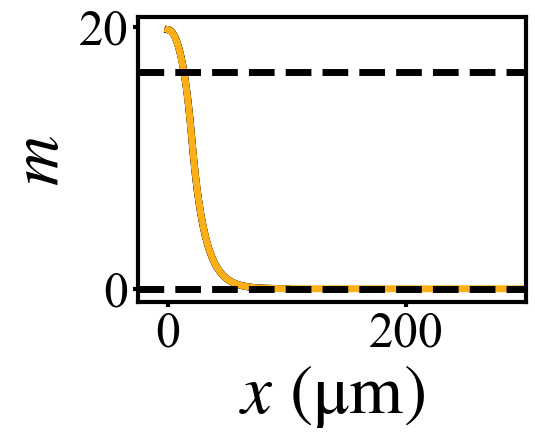

In [ ]:
plt.plot(x0,m_ana_0,color='k')
plt.plot(x0,m_init,color='k')

plt.plot(xf,m_ana_f,color='yellow')
plt.xlim(xmax=300)
plt.xlabel('$x$ $(\\mathrm{\\mu m})$')
plt.ylabel(f'$m$ ')

plt.axhline(m_critical1,c='k',ls='--')
plt.axhline(m_critical2,c='k',ls='--')
# plt.fill_between(x0, m_ana_0, where=(m_ana_0>m_critical1) & (m_ana_0<m_critical2), color='lilac', alpha=0.5)


# bifurcation diagram

In [6]:
# lowest_m = m_critical1 /1000
lowest_m = 0.001
# highest_m = highest_M / Mstar # to match
# highest_m = m_critical2 * 1.3
highest_m = 100
num_m_val = 1000


unstable_m_values, unstable_n1_solArray, unstable_n2_solArray, upper_m_values, upper_n1_solArray, upper_n2_solArray, lower_m_values, lower_n1_solArray, lower_n2_solArray = nd3FuncToggle.find_bifurcation_diagram(m_critical1, m_critical2, p, q, h, v1, v2, k1, k2,
        num_m_val=num_m_val,lowest_m=lowest_m,highest_m=highest_m,
        starting_estimate_higher = [1.5,-2],
        starting_estimate_unstable = [0,1], 
        starting_estimate_lower = [-4,2.5],
        starting_estimate_higher_inputted = False)

/Users/bowena/Documents/GitHub/GrowthPatterningModulesV2/FuncTogglev2/nondimensional3D.py:634: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  unstable_logn1_sol, unstable_logn2_sol = fsolve(difference_in_nullclines, starting_estimate_unstable)
/Users/bowena/Documents/GitHub/GrowthPatterningModulesV2/FuncTogglev2/nondimensional3D.py:661: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  high_logn1_sol, high_logn2_sol = fsolve(difference_in_nullclines, starting_estimate_higher)
/Users/bowena/Documents/GitHub/GrowthPatterningModulesV2/FuncTogglev2/nondimensional3D.py:687: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  low_logn1_sol, low_logn2_sol = fsolve(difference_in_nullclines, starting_estimate_lower)


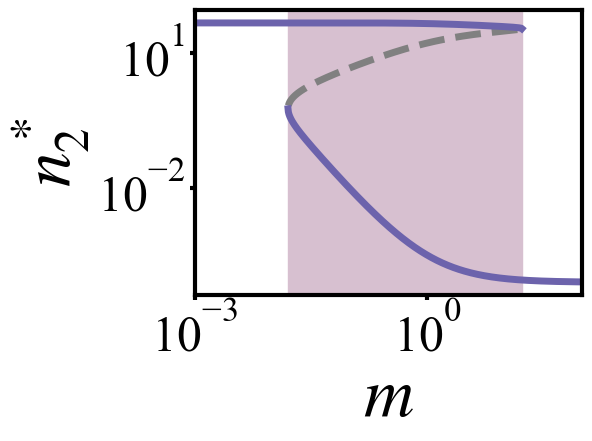

In [ ]:
plt.plot(unstable_m_values,unstable_n2_solArray, color='grey', linestyle='--', label='Unstable fixed point')
plt.plot(upper_m_values,upper_n2_solArray,label='High morphogen fate',color='purple')
plt.plot(lower_m_values,lower_n2_solArray,label='Low morphogen fate',color='purple')

plt.axvspan(m_critical1,m_critical2,color='lilac',label='Bistable region')

# FuncPlot.make_ticks_minimal(x_n_ticks=2, y_n_ticks=4)
# plt.set
plt.xlabel('$m$')
plt.ylabel('$n_2^*$')
plt.xlim(lowest_m,highest_m)
# plt.xticks([0,1,2]) 
# plt.yticks([0,20,40]) 

plt.xscale('log')
plt.yscale('log')

In [ ]:
# No growth 
# # %%%%%%%%%%%% Nondimensional 1D ng simulation - at initial and final length %%%%%%%%%%%%
time_ndArray_ng_f, mArray_ng_f, n1Array_ng_f, n2Array_ng_f = nd3FuncToggle.n1n2m_solver_NoGrowth_fixedm(N,dt_ng,v1,v2,k1,k2,p,h,q,store_no_ng,n1_init,n2_init,m_ana_f,count_max_ng)
time_ndArray_ng_0, mArray_ng_0, n1Array_ng_0, n2Array_ng_0 = nd3FuncToggle.n1n2m_solver_NoGrowth_fixedm(N,dt_ng,v1,v2,k1,k2,p,h,q,store_no_ng,n1_init,n2_init,m_ana_0,count_max_ng)



# nondimensional growing code
timeArray_1D_IC, xArray_1D_IC, mArray_1D_IC, n1Array_1D_IC, n2Array_1D_IC, x_YArray_1D_IC, LArray_1D_IC, wArray_1D_IC = nd3FuncToggle.n1n2m_solver_ConstantGrowth_fixed_source(N,N_1,N_2,w0,D,k,vm,epsilon,sourceSize,dt,dy,v1,v2,k1,k2,h,p,q,L0,store_no,m_ana_0,n1Array_ng_0_eff[-1,:],n2Array_ng_0_eff[-1,:],count_max,g_max)
n1_boundaryArray_1D_IC = dimFuncPatternQuant.find_gene_boundaryArray(n1Array_1D_IC,xArray_1D_IC,sourceSize,fraction,norm_value=n1_amp_eff)
n2_boundaryArray_1D_IC = dimFuncPatternQuant.find_gene_boundaryArray(n2Array_1D_IC,xArray_1D_IC,sourceSize,fraction,norm_value=n2_amp_eff)

# $\tau = \int_{t_c}^{t_c + \tau} dt = \int_{ \tilde{n}_{2}(t=t_c)}^{fv_2/(k_2+g)} d \tilde{n}_2$



The respecification time is found from integrating the time it takes a `cell' (or spatial element) to become the boundary once it has left the bistable region.

In [ ]:
# find tau from the 1D simulation
tau = nd3FuncPatternQuant.quantify_tau_num_1D(n2_boundaryArray_1D_IC,timeArray_1D_IC,xArray_1D_IC,n2Array_1D_IC,max(x_critical1_f,x_critical2_f),g_max,fraction,v2,k2)

# $\chi^* = x_c + \Delta   = x_c e^{g \tau / (1+\varepsilon)} $ 


The maximum boundary position, or extension to scaling.

In [ ]:
# find the chi_star value
chi_star = nd3FuncPatternQuant.find_chi_star_ana_0D_tau_from_xcrit(x_critical1_f,v1,v2,k1,k2,h,p,q,vm,k,D,g_max,epsilon,L0,sourceSize,fraction)

# 0D solver 

Instead of solving the full 1D simulation, we can use a 0D solver to solve for a single `cell' or spatial element.

In [ ]:
# find tau from the 0D simulations
# calculate the max time to simulate for
store_no_0D = 10
x_initial  = 20
t_g = max(nd3FuncAnalytical.find_t_g_constant_growth(sourceSize,g_max,epsilon,x_critical1_f*20),10)
dt_0D = min(t_g/store_no_0D,0.1/(1+g_max))
timeArray_0D_i = np.arange(0,t_g,dt_0D)
n1_init = v1/(k1+g_max)
n2_init = 0
# generate m tilde
m_tilde_i = nd3FuncToggle.find_m_tilde_constant_growth(L0,g_max,epsilon,sourceSize,vm,k,D,x_initial,timeArray_0D_i)
m_tilde_i[np.isnan(m_tilde_i)] = 0
n1Array_for_IC, n2Array_for_IC, timeArray_for_IC, SS_check_n1_for_IC, SS_check_n2_for_IC = nd3FuncToggle.n1n2_0D_Growth_solver(m_tilde_i[0] * np.ones(len(m_tilde_i)),g_max * np.ones(len(m_tilde_i)),v1,v2,k1,k2,h,p,q,dt_0D,n1_init,n2_init)

# 0D simulation
n1Array_0D_i, n2Array_0D_i, timeArray_0D_i, SS_check_n1_0D_i, SS_check_n2_0D_i = nd3FuncToggle.n1n2_0D_Growth_solver(m_tilde_i,g_max*np.ones(len(m_tilde_i)),v1,v2,k1,k2,h,p,q,dt_0D,n1Array_for_IC[-1],n2Array_for_IC[-1])
xArray_0D_i = nd3FuncAnalytical.find_L_ana_constant_growth(x_initial,g_max,epsilon,timeArray_0D_i)
tau_0D = nd3FuncPatternQuant.quantify_tau_num_0D(timeArray_0D_i,n2Array_0D_i,xArray_0D_i,x_critical1_f,fraction,v2,k2,g_max,index_leave_bistable=1)